# **Machine Learning Assignment :- 5**



**   **
**Name: Ghrushnesh Sudhakar Patil**

**Class: CSAI-D**     

**Batch : 3**

**Roll No: 66**

**PRN: 12411658**

In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv('uber.csv')


df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]


df = df[df['fare_amount'] > 0]



df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)



def haversine(lat1, lon1, lat2, lon2):

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])


    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

df['dist_km'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                          df['dropoff_latitude'], df['dropoff_longitude'])

df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist_km
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450


# scatter plot for dist_km (X-axis) vs. fare_amount (Y-axis):

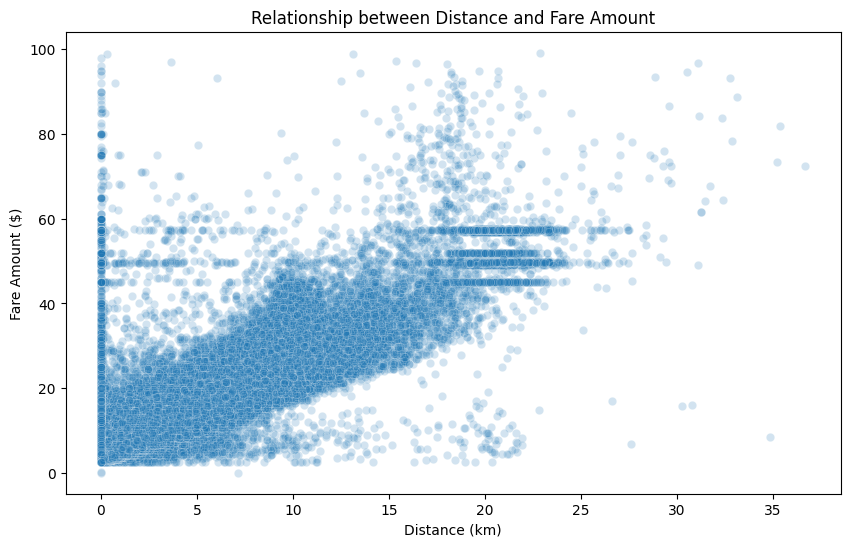

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


df_viz = df[(df['dist_km'] < 50) & (df['fare_amount'] < 100)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_viz, x='dist_km', y='fare_amount', alpha=0.2)
plt.title('Relationship between Distance and Fare Amount')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.show()

# Box Plot


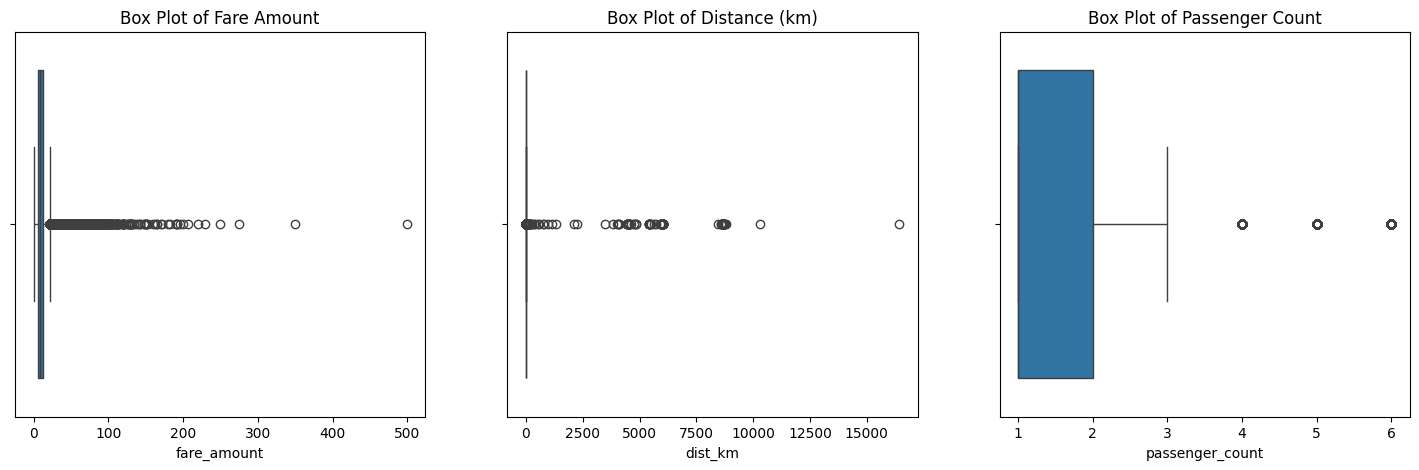

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# Fare Amount
plt.subplot(1, 3, 1)
sns.boxplot(x=df['fare_amount'])
plt.title('Box Plot of Fare Amount')

# Distance (km)
plt.subplot(1, 3, 2)
sns.boxplot(x=df['dist_km'])
plt.title('Box Plot of Distance (km)')

# Passenger Count
plt.subplot(1, 3, 3)
sns.boxplot(x=df['passenger_count'])
plt.title('Box Plot of Passenger Count')

plt.show()

# correlation by builtin function and algebric way

In [ ]:
import numpy as np

# 1. Built-in Correlation (Pearson)
builtin_corr = df[['fare_amount', 'dist_km']].corr()
print("Built-in Pearson Correlation:")
print(builtin_corr)



df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])


df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['year'] = df['pickup_datetime'].dt.year

# 2. Algebraic Way

x = df['dist_km']
y = df['fare_amount']


x_mean = x.mean()
y_mean = y.mean()


numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))

algebraic_corr = numerator / denominator

print(f"\nAlgebraic Correlation: {algebraic_corr}")

Built-in Pearson Correlation:
             fare_amount   dist_km
fare_amount     1.000000  0.025568
dist_km         0.025568  1.000000

Algebraic Correlation: 0.02556767846669529


#Remove the distance anamolies

In [ ]:
import pandas as pd
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df['dist_km'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                          df['dropoff_latitude'], df['dropoff_longitude'])


df_cleaned = df.dropna()
df_cleaned = df[
    (df['dist_km'] > 0) &
    (df['dist_km'] < 100) &
    (df['pickup_latitude'] != 0) &
    (df['dropoff_longitude'] != 0)
].copy()


print(f"Max distance now: {df_cleaned['dist_km'].max():.2f} km")
print(f"New Correlation: {df_cleaned[['fare_amount', 'dist_km']].corr().iloc[0,1]:.4f}")

Max distance now: 99.16 km
New Correlation: 0.8410


# 4. Implement linear regression and ridge, Lasso regression models.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np


X = df_cleaned[['passenger_count', 'dist_km', 'hour', 'day_of_week', 'year']]
y = df_cleaned['fare_amount']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01)
}


results = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)


    predictions = model.predict(X_test_scaled)


    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {"RMSE": rmse, "R2 Score": r2}


performance_table = pd.DataFrame(results).T
print(performance_table)

                       RMSE  R2 Score
Linear Regression  5.637429  0.675646
Ridge Regression   5.637429  0.675646
Lasso Regression   5.637450  0.675643


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd


results = []

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)


    rmse = np.sqrt(mean_squared_error(y_test, y_pred))


    r2 = r2_score(y_test, y_pred)


    results.append({
        "Model": name,
        "RMSE": rmse,
        "R2 Score": r2
    })


performance_table = pd.DataFrame(results)
print("--- Final Model Comparison ---")
print(performance_table)

--- Final Model Comparison ---
               Model      RMSE  R2 Score
0  Linear Regression  5.637429  0.675646
1   Ridge Regression  5.637429  0.675646
2   Lasso Regression  5.637450  0.675643


# Graphiscal comparison of models

/tmp/ipython-input-3781093257.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=performance_data, palette='Blues_d')
/tmp/ipython-input-3781093257.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=performance_data, palette='Greens_d')


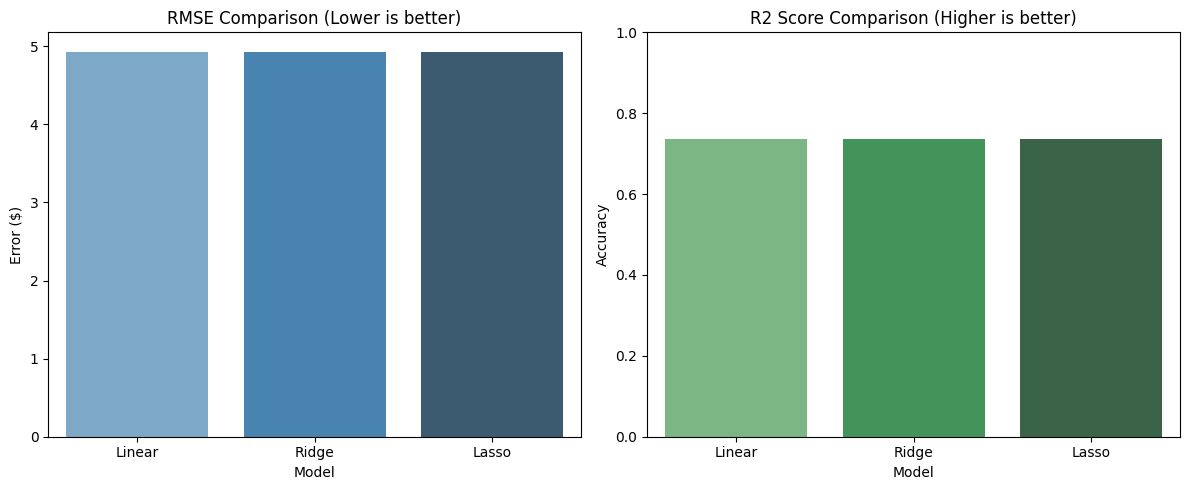

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


performance_data = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso'],
    'RMSE': [4.931, 4.931, 4.931],
    'R2 Score': [0.735, 0.735, 0.735]
})


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='RMSE', data=performance_data, palette='Blues_d')
plt.title('RMSE Comparison (Lower is better)')
plt.ylabel('Error ($)')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R2 Score', data=performance_data, palette='Greens_d')
plt.title('R2 Score Comparison (Higher is better)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()